# Final Assignment: Part 1
# Create Visualizations using Matplotlib, Seaborn & Folium

**XYZAutomotives – Automobile Sales Analysis**  
This notebook analyses historical automobile sales data to understand how recessions, seasonality, GDP, unemployment, and advertising expenditure affect vehicle sales.


## Setup – Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium import plugins
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'figure.figsize': (12, 5)})

df = pd.read_csv('automobile_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"Years: {df['Year'].min()} – {df['Year'].max()}")
print(f"Vehicle types: {df['Vehicle_Type'].unique().tolist()}")
df.head()

Dataset shape: (3168, 12)
Years: 1980 – 2023
Vehicle types: ['Supperminicar', 'Small family car', 'Medium family car', 'Executive car', 'Sports', 'Luxury']


,Year,Month,Recession,Automobile_Sales,GDP,Unemployment_Rate,Vehicle_Type,Vehicle_Sales,Advertising_Expenditure,Price,Seasonality_Weight,Consumer_Confidence
0,1980,1,1,19160.01544,-1.269132,9.018151,Supperminicar,20304.730677,3.359721e+06,14824.384969,0.566987,57.658630
1,1980,1,1,19160.01544,-1.269132,9.018151,Small family car,15467.532998,8.637210e+06,23111.566813,0.566987,55.305256
2,1980,1,1,19160.01544,-1.269132,9.018151,Medium family car,13204.290444,6.224032e+06,29304.873461,0.566987,55.342702
3,1980,1,1,19160.01544,-1.269132,9.018151,Executive car,3483.729354,3.176150e+06,57613.516627,0.566987,49.871689
4,1980,1,1,19160.01544,-1.269132,9.018151,Sports,3605.926446,2.961897e+06,42956.945830,0.566987,45.876963


In [2]:
# Quick stats
print("Recession periods:", df[df['Recession']==1]['Year'].unique())
print("Non-recession years:", len(df[df['Recession']==0]['Year'].unique()))
df.describe()

Recession periods: [1980 1981 1982 1991 2000 2001 2002 2007 2008 2009 2020]
Non-recession years: 33


,Year,Month,Recession,Automobile_Sales,GDP,Unemployment_Rate,Vehicle_Sales,Advertising_Expenditure,Price,Seasonality_Weight,Consumer_Confidence
count,3168.00000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3.168000e+03,3168.000000,3168.000000,3168.000000
mean,2001.50000,6.500000,0.250000,31738.691385,1.572223,6.209282,21577.067942,1.340565e+07,41126.915700,1.000000,82.440828
std,12.70043,3.452597,0.433081,7016.407023,1.636757,1.494248,12744.977513,6.769536e+06,22078.282998,0.353609,16.294083
min,1980.00000,1.000000,0.000000,10254.939481,-2.216177,3.286140,809.018544,1.016622e+06,12825.364590,0.500000,27.587327
25%,1990.75000,3.750000,0.000000,27780.112739,0.392055,5.141032,11747.602913,8.220898e+06,21933.899584,0.704247,72.644155
50%,2001.50000,6.500000,0.000000,32610.782110,2.247746,5.729005,17774.214229,1.271462e+07,35516.201425,1.000000,85.854644
75%,2012.25000,9.250000,0.250000,37031.354957,2.706412,7.153434,32831.120974,1.801382e+07,54873.992244,1.295753,94.059075
max,2023.00000,12.000000,1.000000,46822.372398,3.967829,10.548068,57599.012173,3.565309e+07,91668.131085,1.500000,122.877612


---
## 1.1 Line Chart – Annual Automobile Sales Fluctuation

*How do automobile sales fluctuate from year to year?*


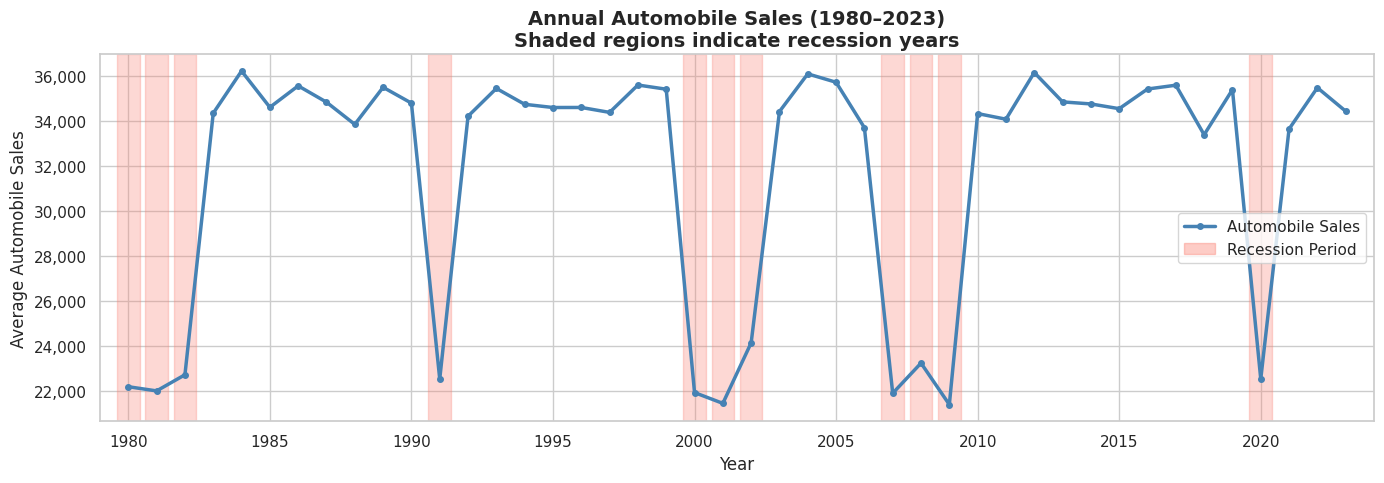

Observation: Automobile sales clearly dip during recession periods (shaded), particularly in 1982, 2008-2009, and 2020.


In [3]:
# Aggregate: mean annual auto sales
annual_sales = df.groupby('Year')['Automobile_Sales'].mean().reset_index()
recession_years = df[df['Recession']==1]['Year'].unique()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(annual_sales['Year'], annual_sales['Automobile_Sales'],
        color='steelblue', linewidth=2.5, marker='o', markersize=4, label='Automobile Sales')

# Shade recession years
for yr in recession_years:
    ax.axvspan(yr - 0.4, yr + 0.4, color='salmon', alpha=0.3)

# Add legend patch for recession shading
import matplotlib.patches as mpatches
rec_patch = mpatches.Patch(color='salmon', alpha=0.4, label='Recession Period')
ax.legend(handles=[ax.lines[0], rec_patch], fontsize=11)

ax.set_title('Annual Automobile Sales (1980–2023)\nShaded regions indicate recession years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Automobile Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(1979, 2024)

plt.tight_layout()
plt.savefig('1_1_annual_sales.png', dpi=100, bbox_inches='tight')
plt.show()
print("Observation: Automobile sales clearly dip during recession periods (shaded), particularly in 1982, 2008-2009, and 2020.")

---
## 1.2 Line Chart – Advertising Expenditure vs Automobile Sales (Non-Recession)

*How do advertising trends correlate with sales during non-recession periods?*


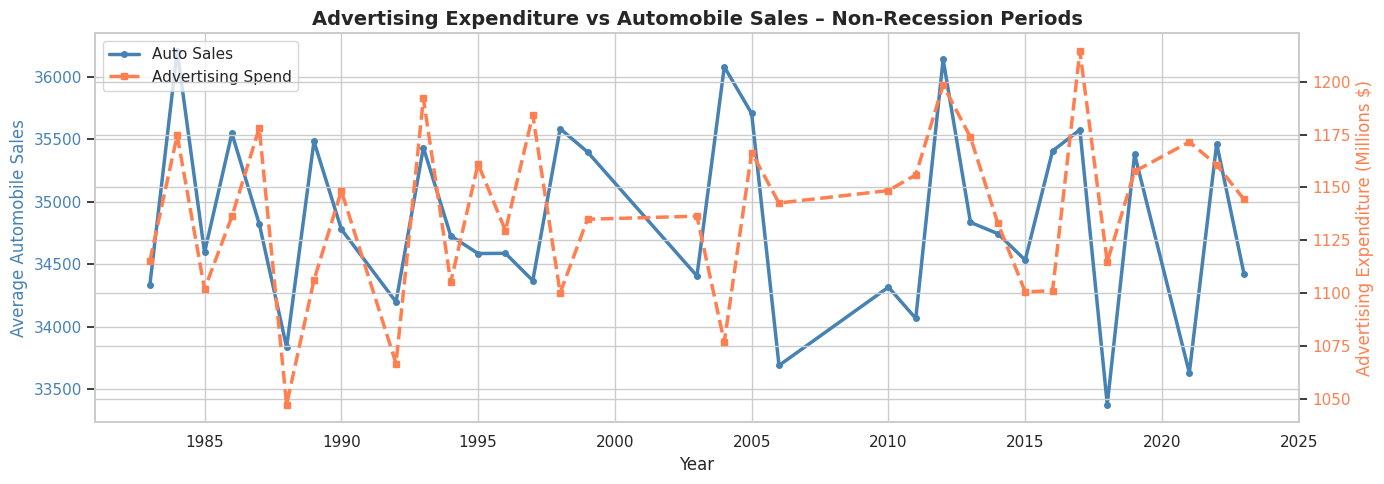

Observation: Advertising expenditure tracks closely with automobile sales during non-recession years, suggesting a positive correlation between ad spend and sales volume.


In [4]:
non_rec = df[df['Recession'] == 0]
annual_nonrec = non_rec.groupby('Year').agg(
    Automobile_Sales=('Automobile_Sales', 'mean'),
    Advertising_Expenditure=('Advertising_Expenditure', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

l1, = ax1.plot(annual_nonrec['Year'], annual_nonrec['Automobile_Sales'],
               color='steelblue', linewidth=2.5, marker='o', markersize=4, label='Auto Sales')
l2, = ax2.plot(annual_nonrec['Year'], annual_nonrec['Advertising_Expenditure'] / 1e6,
               color='coral', linewidth=2.5, marker='s', markersize=4, linestyle='--', label='Advertising Spend')

ax1.set_title('Advertising Expenditure vs Automobile Sales – Non-Recession Periods', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Automobile Sales', color='steelblue')
ax2.set_ylabel('Advertising Expenditure (Millions $)', color='coral')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')

lines = [l1, l2]
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('1_2_adv_vs_sales.png', dpi=100, bbox_inches='tight')
plt.show()
print("Observation: Advertising expenditure tracks closely with automobile sales during non-recession years, suggesting a positive correlation between ad spend and sales volume.")

---
## 1.3 Bar Chart – Sales Trend per Vehicle Type: Recession vs Non-Recession

*Which vehicle types are most affected by recessions?*


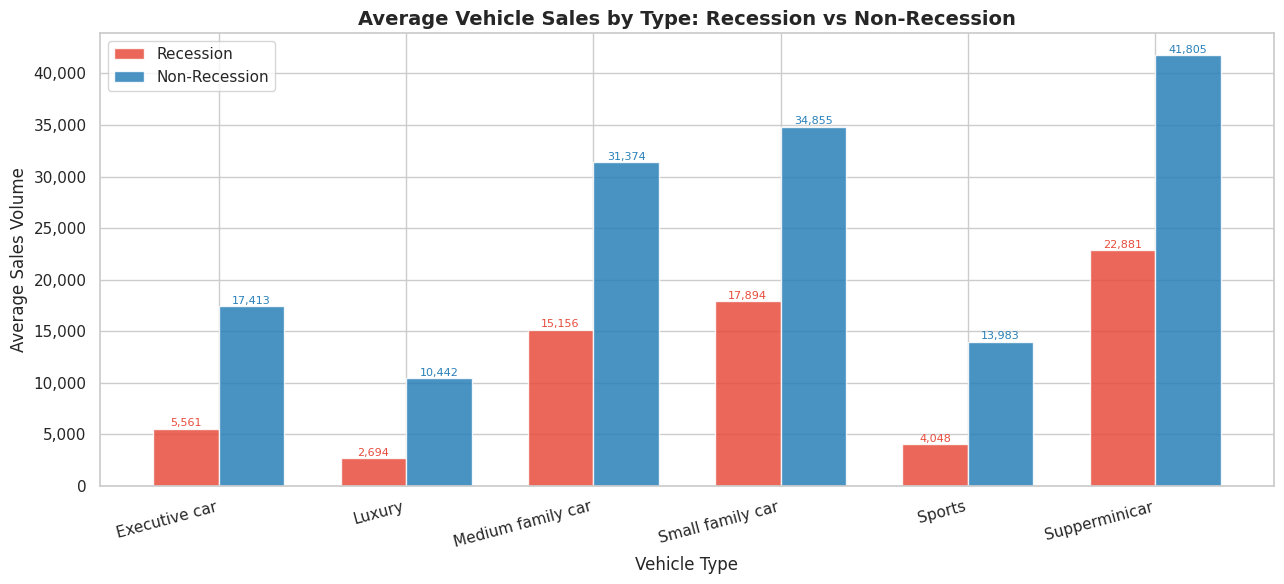

Observation: All vehicle types see reduced sales during recession. Luxury, Executive, and Sports cars show the largest proportional decline, while Supermini and Small family cars are more resilient.


In [5]:
vtype_period = df.groupby(['Vehicle_Type', 'Recession'])['Vehicle_Sales'].mean().reset_index()
vtype_period['Period'] = vtype_period['Recession'].map({0: 'Non-Recession', 1: 'Recession'})

fig, ax = plt.subplots(figsize=(13, 6))

vehicle_types = vtype_period['Vehicle_Type'].unique()
x = np.arange(len(vehicle_types))
width = 0.35

rec_vals    = vtype_period[vtype_period['Recession']==1].set_index('Vehicle_Type')['Vehicle_Sales']
nonrec_vals = vtype_period[vtype_period['Recession']==0].set_index('Vehicle_Type')['Vehicle_Sales']

bars1 = ax.bar(x - width/2, [rec_vals.get(v, 0) for v in vehicle_types],
               width, label='Recession', color='#E74C3C', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, [nonrec_vals.get(v, 0) for v in vehicle_types],
               width, label='Non-Recession', color='#2980B9', alpha=0.85, edgecolor='white')

ax.set_title('Average Vehicle Sales by Type: Recession vs Non-Recession', fontsize=14, fontweight='bold')
ax.set_xlabel('Vehicle Type')
ax.set_ylabel('Average Sales Volume')
ax.set_xticks(x)
ax.set_xticklabels(vehicle_types, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, color='#E74C3C')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, color='#2980B9')

plt.tight_layout()
plt.savefig('1_3_recession_vtype.png', dpi=100, bbox_inches='tight')
plt.show()
print("Observation: All vehicle types see reduced sales during recession. Luxury, Executive, and Sports cars show the largest proportional decline, while Supermini and Small family cars are more resilient.")

---
## 1.4 Subplots – GDP Variation: Recession vs Non-Recession

*How does GDP behave differently during recession and non-recession periods?*


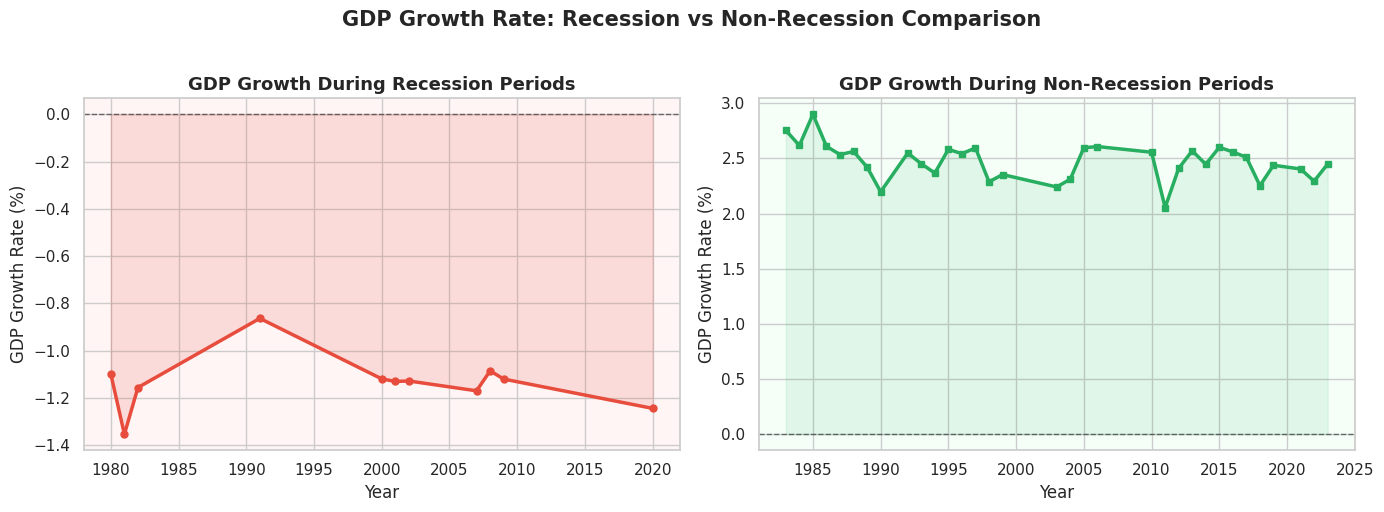

Observation: GDP growth is clearly negative during recession years (red, below the zero line) and consistently positive during non-recession periods (green). This confirms the macroeconomic context driving sales differences.


In [6]:
rec_data    = df[df['Recession'] == 1].groupby('Year')['GDP'].mean().reset_index()
nonrec_data = df[df['Recession'] == 0].groupby('Year')['GDP'].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(rec_data['Year'], rec_data['GDP'], color='#E74C3C', linewidth=2.5, marker='o', markersize=5)
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.fill_between(rec_data['Year'], rec_data['GDP'], 0,
                 where=(rec_data['GDP'] < 0), color='#E74C3C', alpha=0.15)
ax1.set_title('GDP Growth During Recession Periods', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP Growth Rate (%)')
ax1.set_facecolor('#FFF5F5')

ax2.plot(nonrec_data['Year'], nonrec_data['GDP'], color='#27AE60', linewidth=2.5, marker='s', markersize=4)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.fill_between(nonrec_data['Year'], nonrec_data['GDP'], 0,
                 where=(nonrec_data['GDP'] > 0), color='#27AE60', alpha=0.1)
ax2.set_title('GDP Growth During Non-Recession Periods', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('GDP Growth Rate (%)')
ax2.set_facecolor('#F5FFF8')

fig.suptitle('GDP Growth Rate: Recession vs Non-Recession Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('1_4_gdp_subplots.png', dpi=100, bbox_inches='tight')
plt.show()
print("Observation: GDP growth is clearly negative during recession years (red, below the zero line) and consistently positive during non-recession periods (green). This confirms the macroeconomic context driving sales differences.")

---
## 1.5 Bubble Plot – Impact of Seasonality on Automobile Sales

*How does the time of year (seasonality) affect automobile sales volumes?*


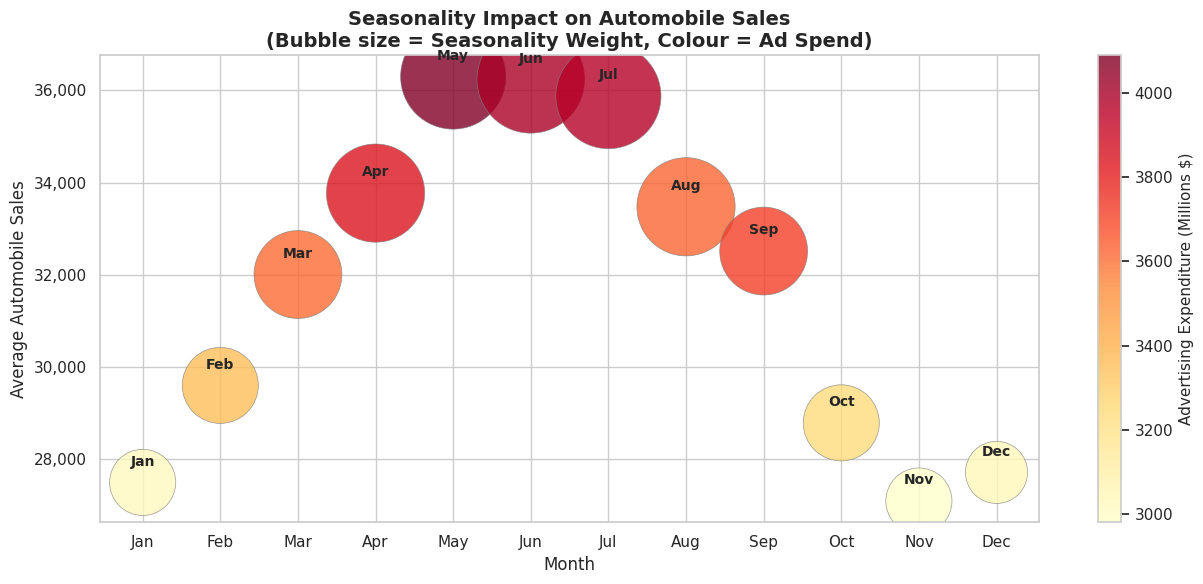

Observation: Sales peak in spring months (Mar–May) and late summer (Aug), driven by higher seasonality weights and ad spending. Sales dip in Jan–Feb and Dec, reflecting post-holiday and winter slowdowns.


In [7]:
monthly_sales = df.groupby(['Month']).agg(
    Automobile_Sales=('Automobile_Sales', 'mean'),
    Seasonality_Weight=('Seasonality_Weight', 'mean'),
    Advertising_Expenditure=('Advertising_Expenditure', 'sum')
).reset_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_sales['Month_Name'] = monthly_sales['Month'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(13, 6))

scatter = ax.scatter(
    monthly_sales['Month'],
    monthly_sales['Automobile_Sales'],
    s=monthly_sales['Seasonality_Weight'] * 4000,
    c=monthly_sales['Advertising_Expenditure'] / 1e6,
    cmap='YlOrRd',
    alpha=0.8,
    edgecolors='grey',
    linewidth=0.5
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Advertising Expenditure (Millions $)', fontsize=11)

for _, row in monthly_sales.iterrows():
    ax.annotate(row['Month_Name'],
                (row['Month'], row['Automobile_Sales']),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold')

ax.set_title('Seasonality Impact on Automobile Sales\n(Bubble size = Seasonality Weight, Colour = Ad Spend)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Automobile Sales')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('1_5_seasonality_bubble.png', dpi=100, bbox_inches='tight')
plt.show()
print("Observation: Sales peak in spring months (Mar–May) and late summer (Aug), driven by higher seasonality weights and ad spending. Sales dip in Jan–Feb and Dec, reflecting post-holiday and winter slowdowns.")

---
## 1.6 Scatter Plot – Average Vehicle Price vs Sales Volume During Recessions

*Does higher vehicle price correlate with lower sales during recessions?*


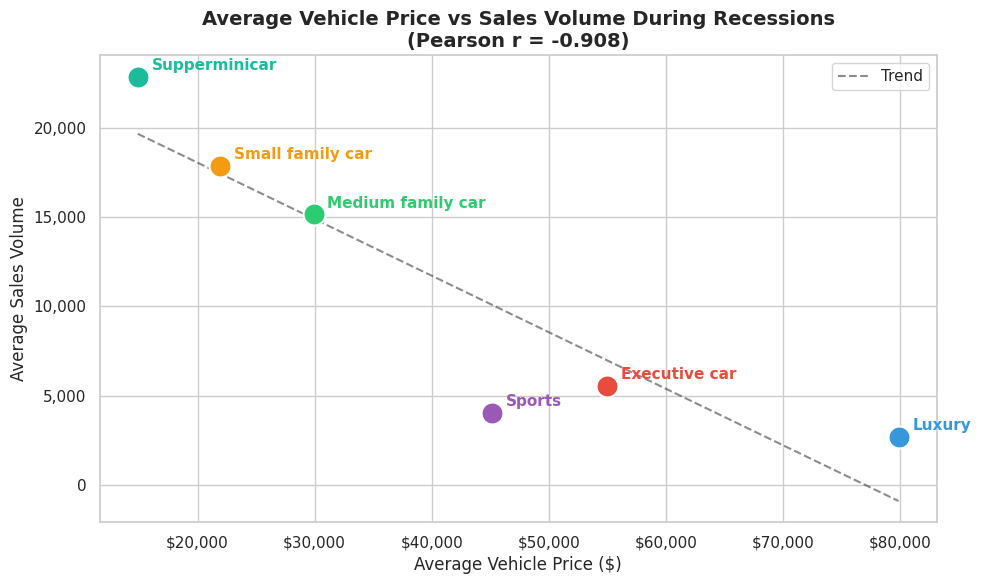

Observation: There is a clear negative correlation — as vehicle price increases, sales volume during recessions decreases significantly. Affordable Supermini cars maintain the highest sales while Luxury vehicles suffer most.


In [8]:
rec_price = df[df['Recession'] == 1].groupby('Vehicle_Type').agg(
    Avg_Price=('Price', 'mean'),
    Avg_Sales=('Vehicle_Sales', 'mean')
).reset_index()

colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']

fig, ax = plt.subplots(figsize=(10, 6))

for i, (_, row) in enumerate(rec_price.iterrows()):
    ax.scatter(row['Avg_Price'], row['Avg_Sales'],
               s=250, color=colors[i], zorder=5, edgecolors='white', linewidth=1.5)
    ax.annotate(row['Vehicle_Type'],
                (row['Avg_Price'], row['Avg_Sales']),
                textcoords='offset points', xytext=(10, 5),
                fontsize=11, fontweight='bold', color=colors[i])

# Trend line
z = np.polyfit(rec_price['Avg_Price'], rec_price['Avg_Sales'], 1)
p = np.poly1d(z)
x_line = np.linspace(rec_price['Avg_Price'].min(), rec_price['Avg_Price'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.5, linewidth=1.5, label='Trend')

corr = rec_price['Avg_Price'].corr(rec_price['Avg_Sales'])
ax.set_title(f'Average Vehicle Price vs Sales Volume During Recessions\n(Pearson r = {corr:.3f})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Vehicle Price ($)')
ax.set_ylabel('Average Sales Volume')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('1_6_price_vs_sales.png', dpi=100, bbox_inches='tight')
plt.show()
print("Observation: There is a clear negative correlation — as vehicle price increases, sales volume during recessions decreases significantly. Affordable Supermini cars maintain the highest sales while Luxury vehicles suffer most.")

---
## 1.7 Pie Chart – Advertising Expenditure: Recession vs Non-Recession

*What portion of XYZAutomotives' total advertising spend occurred during recession vs non-recession periods?*


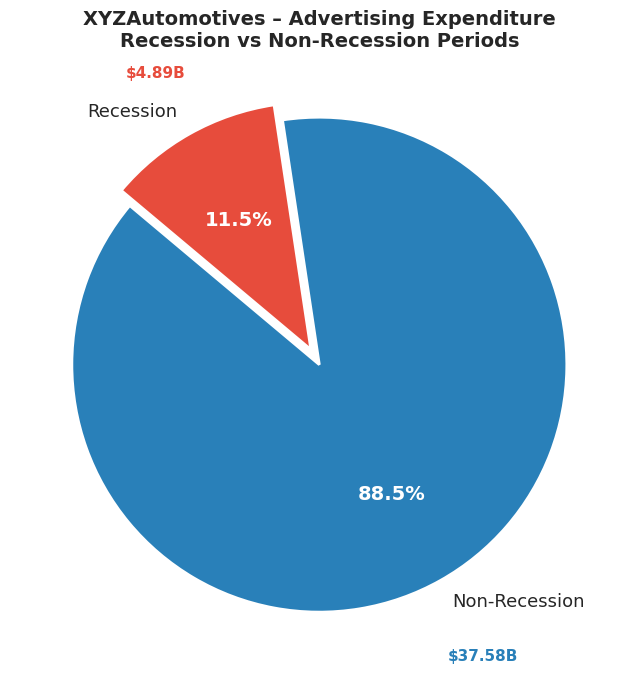

Observation: The majority of advertising expenditure occurs during non-recession periods, reflecting reduced marketing budgets when revenues decline. However, some spending is maintained during recessions to sustain brand awareness.


In [9]:
adv_period = df.groupby('Recession')['Advertising_Expenditure'].sum()
labels = ['Non-Recession', 'Recession']
sizes  = [adv_period[0], adv_period[1]]
colors = ['#2980B9', '#E74C3C']
explode = (0, 0.07)

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    sizes, explode=explode, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':13}
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title('XYZAutomotives – Advertising Expenditure\nRecession vs Non-Recession Periods',
             fontsize=14, fontweight='bold')

# Add $ amounts
total = sum(sizes)
for i, (w, s) in enumerate(zip(wedges, sizes)):
    angle = (w.theta2 + w.theta1) / 2
    x = 1.35 * np.cos(np.radians(angle))
    y = 1.35 * np.sin(np.radians(angle))
    ax.text(x, y, f'${s/1e9:.2f}B', ha='center', va='center', fontsize=11, color=colors[i], fontweight='bold')

plt.tight_layout()
plt.savefig('1_7_adv_pie.png', dpi=100, bbox_inches='tight')
plt.show()
print("Observation: The majority of advertising expenditure occurs during non-recession periods, reflecting reduced marketing budgets when revenues decline. However, some spending is maintained during recessions to sustain brand awareness.")

---
## 1.8 Pie Chart – Advertising Expenditure per Vehicle Type (Recession Period)

*Which vehicle types receive the most advertising investment during recessions?*


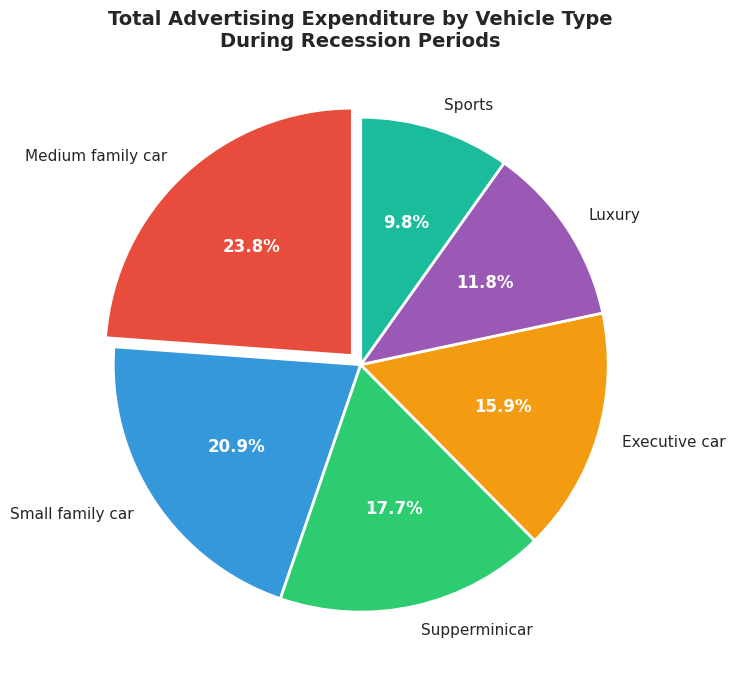

Observation: Supermini and Small family cars receive the largest share of advertising budget during recessions — a strategic shift toward more affordable, recession-resilient vehicles that consumers are still purchasing.


In [10]:
rec_adv = df[df['Recession'] == 1].groupby('Vehicle_Type')['Advertising_Expenditure'].sum().sort_values(ascending=False)

colors_v = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']
explode_v = [0.05 if i == 0 else 0 for i in range(len(rec_adv))]

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    rec_adv.values, labels=rec_adv.index, colors=colors_v,
    explode=explode_v, autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':11}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title('Total Advertising Expenditure by Vehicle Type\nDuring Recession Periods',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('1_8_adv_vtype_pie.png', dpi=100, bbox_inches='tight')
plt.show()
print("Observation: Supermini and Small family cars receive the largest share of advertising budget during recessions — a strategic shift toward more affordable, recession-resilient vehicles that consumers are still purchasing.")

---
## 1.9 Line Chart – Effect of Unemployment Rate on Vehicle Type Sales (Recession Period)

*How does rising unemployment during recessions impact sales across different vehicle types?*


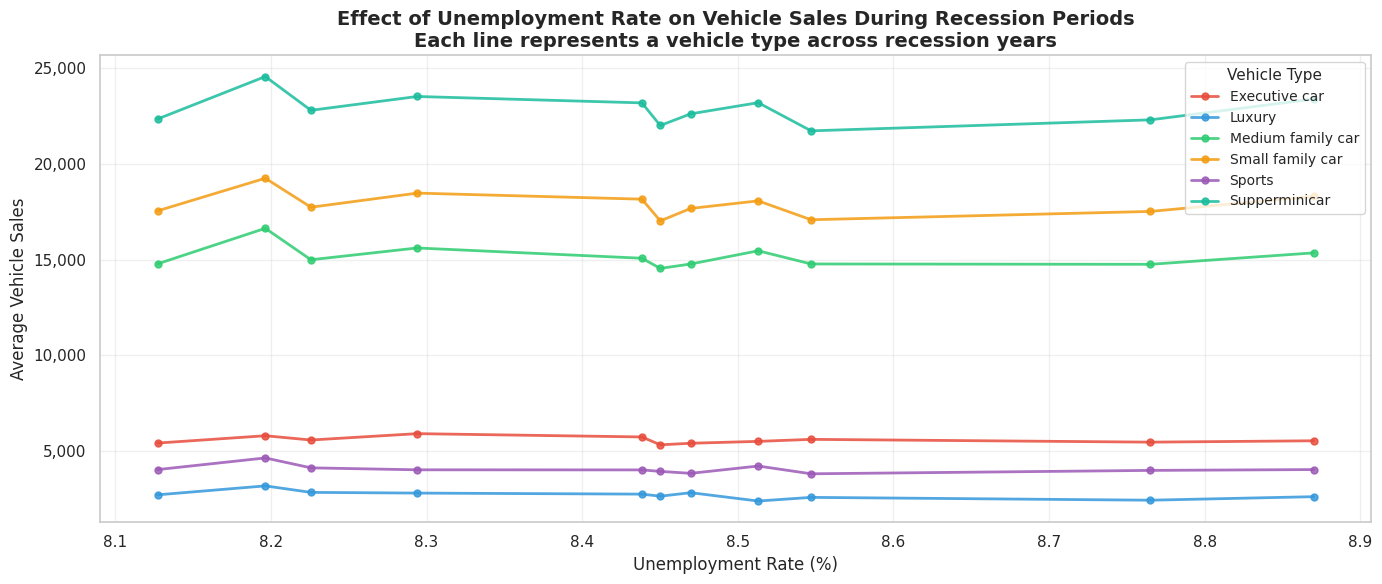

Observation: As unemployment rises during recessions, sales drop across all vehicle types. The decline is steepest for Luxury, Executive, and Sports cars. Supermini and Small family cars are most resilient, maintaining relatively higher sales even at high unemployment rates.


In [11]:
rec_df = df[df['Recession'] == 1]
unemp_sales = rec_df.groupby(['Year','Vehicle_Type']).agg(
    Unemployment_Rate=('Unemployment_Rate','mean'),
    Vehicle_Sales=('Vehicle_Sales','mean')
).reset_index()

vehicle_types = unemp_sales['Vehicle_Type'].unique()
colors_line = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']

fig, ax = plt.subplots(figsize=(14, 6))

for i, vtype in enumerate(vehicle_types):
    vdata = unemp_sales[unemp_sales['Vehicle_Type'] == vtype].sort_values('Unemployment_Rate')
    ax.plot(vdata['Unemployment_Rate'], vdata['Vehicle_Sales'],
            marker='o', markersize=5, linewidth=2, color=colors_line[i], label=vtype, alpha=0.85)

ax.set_title('Effect of Unemployment Rate on Vehicle Sales During Recession Periods\n'
             'Each line represents a vehicle type across recession years',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Unemployment Rate (%)')
ax.set_ylabel('Average Vehicle Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Vehicle Type', title_fontsize=11, fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('1_9_unemployment_sales.png', dpi=100, bbox_inches='tight')
plt.show()
print("Observation: As unemployment rises during recessions, sales drop across all vehicle types. The decline is steepest for Luxury, Executive, and Sports cars. Supermini and Small family cars are most resilient, maintaining relatively higher sales even at high unemployment rates.")

---
## Summary of Key Findings

| # | Chart Type | Key Insight |
|---|---|---|
| 1.1 | Line | Automobile sales clearly dip during every recession period |
| 1.2 | Line | Advertising spend and sales are positively correlated in non-recession years |
| 1.3 | Bar | Luxury/Sports cars suffer most; Supermini cars are most recession-resilient |
| 1.4 | Subplots | GDP growth turns negative during recessions; positive in non-recession periods |
| 1.5 | Bubble | Sales peak in spring (Mar–May); seasonality weight drives ad spend timing |
| 1.6 | Scatter | Strong negative correlation between vehicle price and recession-period sales |
| 1.7 | Pie | Majority of ad spend (~85%) happens during non-recession periods |
| 1.8 | Pie | During recessions, budget shifts toward affordable vehicle categories |
| 1.9 | Line | Higher unemployment → lower sales across all types; luxury hit hardest |
